### Question4:

A)

###### In the case of complete linkage, the fusion will occur higher on the tree as Complete linkage depends on the maximum  intercluster dissimilarity as the dissimalirity of the group.


B)

###### With two points, the fusion will occur at the same height as the minimal (for single) and maximal (for complete) intercluster distance will be same.

### Question11:

In [16]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

In [2]:
np.random.seed(0)

In [3]:
def Pca(matrix,M):
    #print(matrix)
    #scaler =StandardScaler()
    #X_scaled = scaler.fit_transform(matrix) 
    P, D, Q = np.linalg.svd(matrix, full_matrices=False)
    #print(P)
    
    rebuilt_matrix = P[:,:M] @ np.diag(D)[:M,:M] @ Q[:M,:]
    
    
    return rebuilt_matrix
    
    

In [4]:
def error_function(real_matrix,nans_where,pca_matrix):
    indexlisttranspose = np.array(nans_where).T.tolist()
    real_matrix[tuple(indexlisttranspose)]=0
    pca_matrix[tuple(indexlisttranspose)]=0
    error = np.mean(np.square(real_matrix-pca_matrix))
    return error
    

In [5]:
def PCA_imputation(X,dimension, relative_error=1e-7, max_iterations=1000):
    nans_dict={}
    errors_list=[]
    nans_where= np.argwhere(np.isnan(X))
    X_hat =X.copy()
    i=1
    imputes_dict={}
    indexlisttranspose = np.array(nans_where).T.tolist()
    mss0=np.nanmean(np.square(X))
    #print(X)
    #print(np.square(X))
    #print(np.nanmean(np.square(X)))
    #print(X_hat)
    for j in range(X.shape[1]):
        nans_dict[j] = np.argwhere(np.isnan(X[:,j]))
        
        imputes_dict[j] = np.nanmean(X[:,j],axis=0)
        X_hat[nans_dict[j],j] = imputes_dict[j]
   
    #print(X_hat)
    pca_rebuilt_matrix = Pca(X_hat,dimension)
    for j in range(pca_rebuilt_matrix.shape[1]):
        X_hat[nans_dict[j],j] = pca_rebuilt_matrix[nans_dict[j],j]
    error = error_function(X.copy(),nans_where,pca_rebuilt_matrix.copy())
    old_err = error
    errors_list.append(old_err)
    #print(old_err)
    while i <= max_iterations:
        #print(nans_where)
        pca_rebuilt_matrix = Pca(X_hat,dimension)
        #print(pca_rebuilt_matrix.shape)
        
        for j in range(pca_rebuilt_matrix.shape[1]):
            X_hat[nans_dict[j],j] = pca_rebuilt_matrix[nans_dict[j],j]
        new_err = error_function(X.copy(),nans_where,pca_rebuilt_matrix.copy())
        #print(new_err)
        rel_err = (old_err-new_err)/mss0
        #print(rel_err)
        errors_list.append(new_err)
        old_err = new_err 
        if rel_err < relative_error:
            print(f"The algorithm converges after {i} iterations")
            break
            
        i+=1
            
        
        
        
   
    return X_hat,errors_list
    
    
        

In [6]:
d=np.array([[np.nan,0.3,2.0, np.nan],[8.0,1.3,np.nan, np.nan],[11.4,2.3,2.8, 0.5],[np.nan,np.nan,2.8, 0.7]])
#print(np.argwhere(np.isnan(d)))
PCA_imputation(d.copy(),dimension=1)

The algorithm converges after 59 iterations


(array([[ 5.97071359,  0.3       ,  2.        ,  0.32154058],
        [ 8.        ,  1.3       ,  2.10223646,  0.43048696],
        [11.4       ,  2.3       ,  2.8       ,  0.5       ],
        [10.74795049,  1.79781003,  2.8       ,  0.7       ]]),
 [np.float64(0.12056451852179166),
  np.float64(0.11013468155494827),
  np.float64(0.10369165347652001),
  np.float64(0.09807290682455576),
  np.float64(0.09305777726293495),
  np.float64(0.08858435933977024),
  np.float64(0.08460346806629272),
  np.float64(0.08106939655323304),
  np.float64(0.07793924519690043),
  np.float64(0.07517294115118757),
  np.float64(0.07273328122802054),
  np.float64(0.0705859305165542),
  np.float64(0.06869937603250013),
  np.float64(0.0670448430006524),
  np.float64(0.06559618193583144),
  np.float64(0.06432973408152386),
  np.float64(0.06322418192007742),
  np.float64(0.062260390555868975),
  np.float64(0.06142124485692747),
  np.float64(0.06069148636064123),
  np.float64(0.060057553132544975),
  np.float64(0.

In [7]:
PCA_imputation(d.copy(),dimension=2)

The algorithm converges after 78 iterations


(array([[ 9.33271903,  0.3       ,  2.        ,  1.27117689],
        [ 8.        ,  1.3       ,  1.91513581,  0.52338994],
        [11.4       ,  2.3       ,  2.8       ,  0.5       ],
        [11.54567964,  1.98498269,  2.8       ,  0.7       ]]),
 [np.float64(0.01789597849811738),
  np.float64(0.01247932551876655),
  np.float64(0.010613682560772355),
  np.float64(0.009321103188282064),
  np.float64(0.008273946443214353),
  np.float64(0.007405866190767925),
  np.float64(0.006678883035343815),
  np.float64(0.0060639441740410974),
  np.float64(0.005538207391992676),
  np.float64(0.005083716861701407),
  np.float64(0.004686371498740488),
  np.float64(0.0043350969938022515),
  np.float64(0.004021191165920796),
  np.float64(0.0037378129503968377),
  np.float64(0.0034795866225069394),
  np.float64(0.0032422961732641417),
  np.float64(0.0030226487834712256),
  np.float64(0.0028180903096201473),
  np.float64(0.0026266592768872084),
  np.float64(0.0024468689933401988),
  np.float64(0.00227761

In [14]:
from ISLP import load_data
boston_df = load_data("Boston")
#boston_df.drop('Unnamed: 0',axis=1,inplace=True)
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [17]:
data_total = StandardScaler().fit_transform(boston_df)

In [18]:
scaled_df = pd.DataFrame(data_total,index= boston_df.index,columns= boston_df.columns)

In [19]:
scaled_df.mean(axis=0)

crim      -1.123388e-16
zn         7.898820e-17
indus      2.106352e-16
chas      -3.510587e-17
nox       -1.965929e-16
rm        -1.088282e-16
age       -1.474446e-16
dis       -8.425408e-17
rad       -1.123388e-16
tax        0.000000e+00
ptratio   -4.212704e-16
lstat     -3.089316e-16
medv      -5.195668e-16
dtype: float64

###### For nulls_percentage= 5%

In [20]:
cleared_df = scaled_df.mask(np.random.random(scaled_df.shape) < .05)
cleared_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     485 non-null    float64
 1   zn       470 non-null    float64
 2   indus    482 non-null    float64
 3   chas     478 non-null    float64
 4   nox      482 non-null    float64
 5   rm       495 non-null    float64
 6   age      489 non-null    float64
 7   dis      480 non-null    float64
 8   rad      475 non-null    float64
 9   tax      478 non-null    float64
 10  ptratio  466 non-null    float64
 11  lstat    485 non-null    float64
 12  medv     480 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [21]:
data_array = cleared_df.to_numpy(dtype='float', na_value=np.nan)


The algorithm converges after 5 iterations
The algorithm converges after 6 iterations
The algorithm converges after 8 iterations
The algorithm converges after 107 iterations
The algorithm converges after 347 iterations
The algorithm converges after 416 iterations
The algorithm converges after 706 iterations


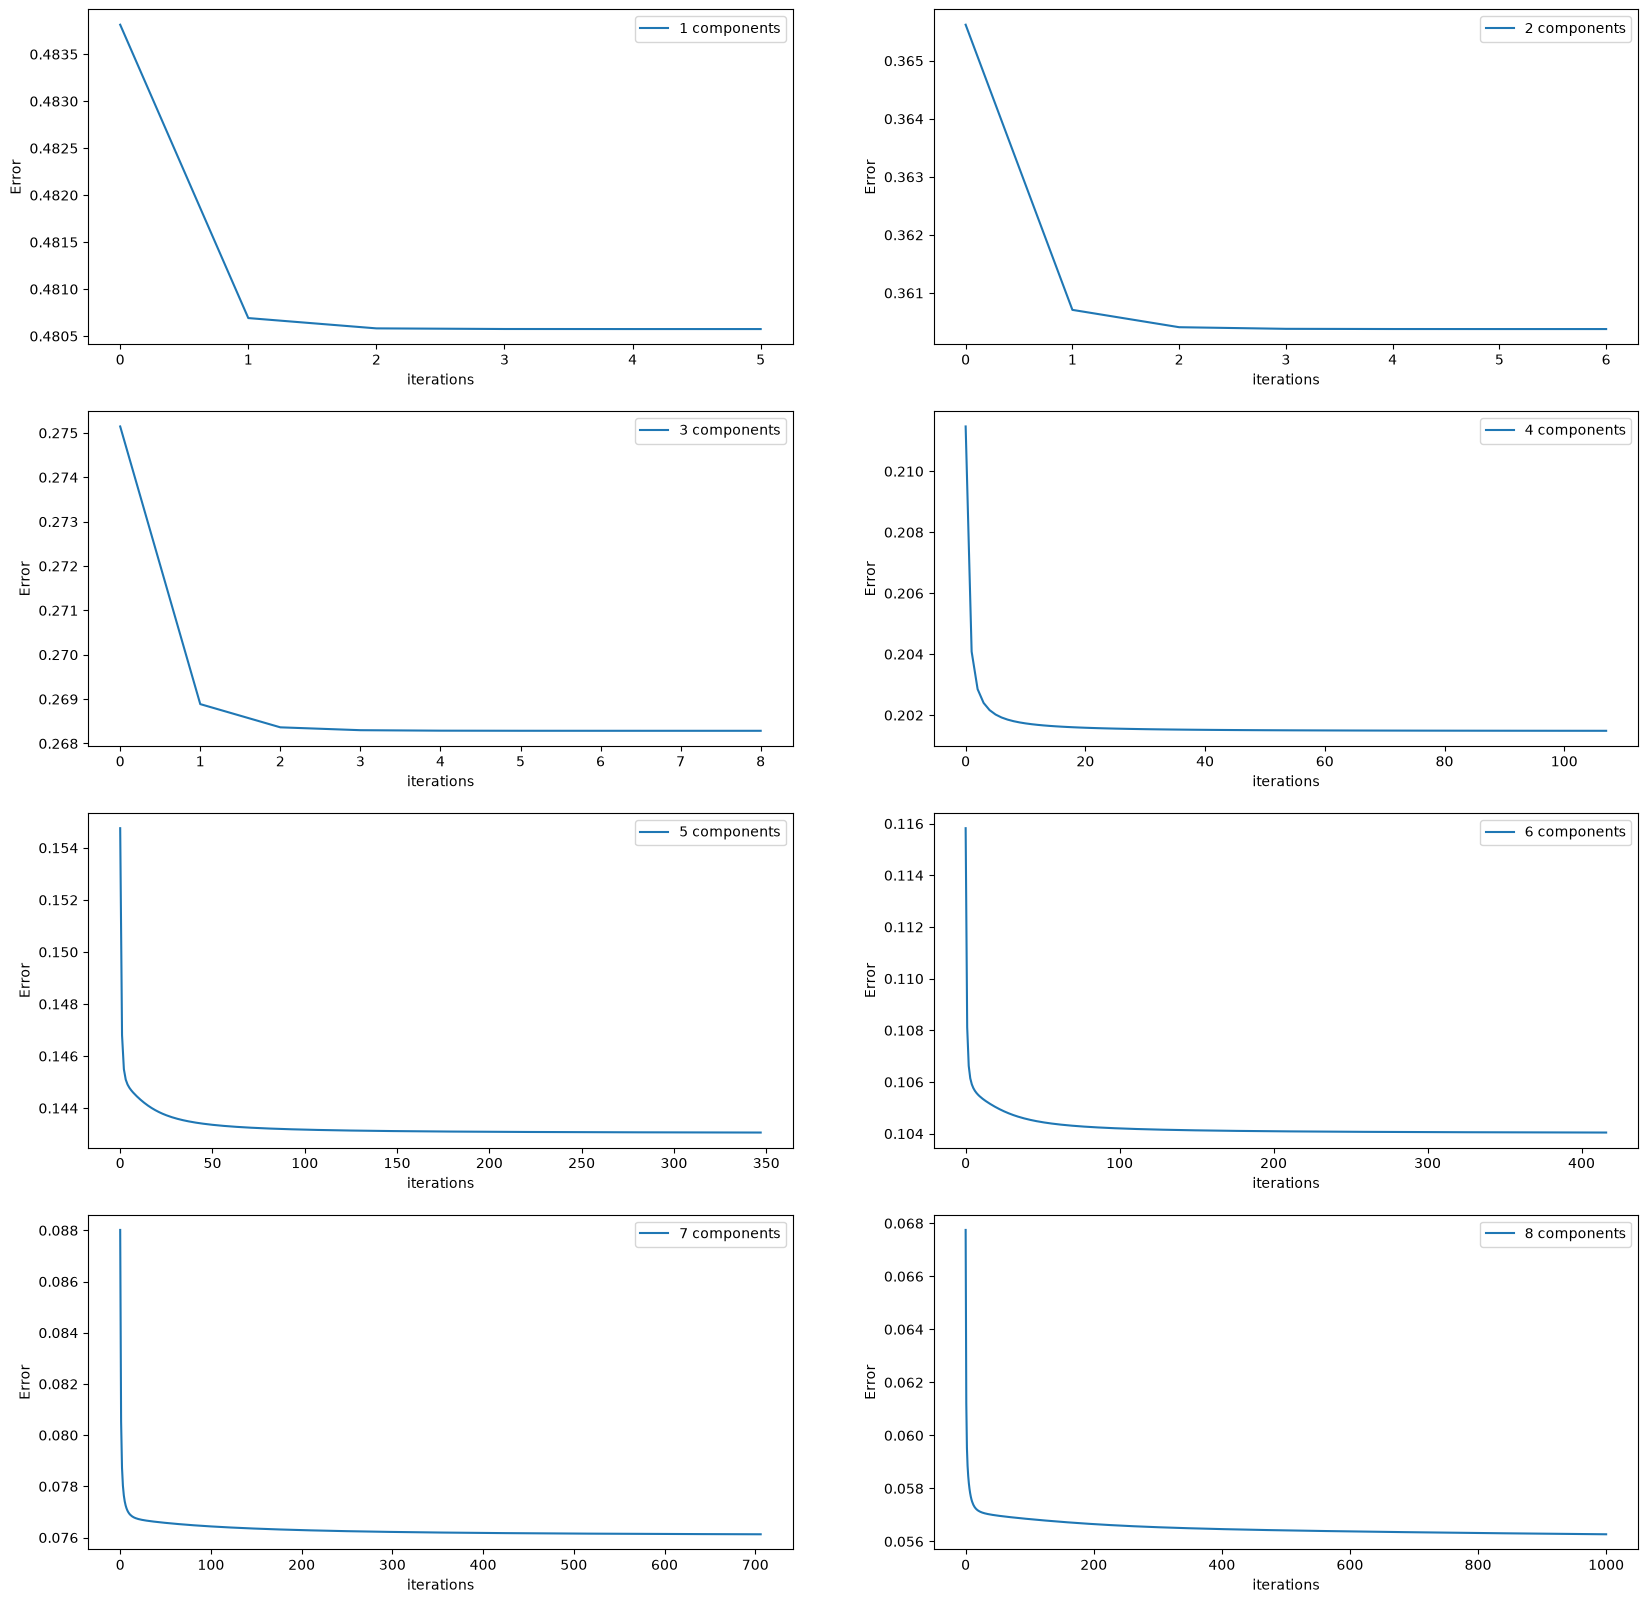

In [22]:

coefs={}
fig =plt.figure(figsize=(20,20))
value = 421
for d in range(1,9):
    data_matrix,errors_list = PCA_imputation(data_array.copy(),dimension=d)
    #print(min(errors_list))
    ax = fig.add_subplot(value)
    ax.plot([x for x in range(len(errors_list))],errors_list,label =f"{d} components")
    ax.set_xlabel("iterations")
    ax.set_ylabel("Error")
    nans_where= np.argwhere(np.isnan(data_array))
    indexlisttranspose = np.array(nans_where).T.tolist()
    X = data_total[tuple(indexlisttranspose)]

    y = data_matrix[tuple(indexlisttranspose)]

    coefs[d]=np.corrcoef(X,y)[1,0]
    ax.legend()
    
    value+=1
plt.show()
    
    

    

Text(0.5, 0, 'Principal Components(M)')

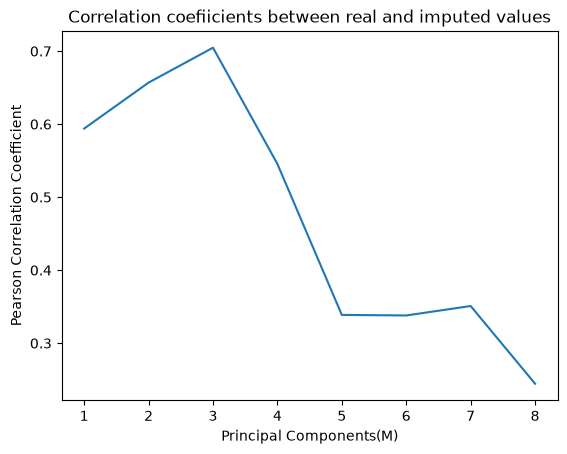

In [23]:
plt.plot(list(coefs.keys()),list(coefs.values()))
plt.title("Correlation coefiicients between real and imputed values")
plt.ylabel("Pearson Correlation Coefficient")
plt.xlabel("Principal Components(M)")

#### For nulls_percentage =10%

In [24]:
cleared_df = scaled_df.mask(np.random.random(scaled_df.shape) < .1)
cleared_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     455 non-null    float64
 1   zn       444 non-null    float64
 2   indus    463 non-null    float64
 3   chas     458 non-null    float64
 4   nox      449 non-null    float64
 5   rm       466 non-null    float64
 6   age      442 non-null    float64
 7   dis      446 non-null    float64
 8   rad      446 non-null    float64
 9   tax      441 non-null    float64
 10  ptratio  460 non-null    float64
 11  lstat    453 non-null    float64
 12  medv     456 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [25]:
data_array = cleared_df.to_numpy(dtype='float', na_value=np.nan)


The algorithm converges after 8 iterations
The algorithm converges after 9 iterations
The algorithm converges after 15 iterations
The algorithm converges after 53 iterations


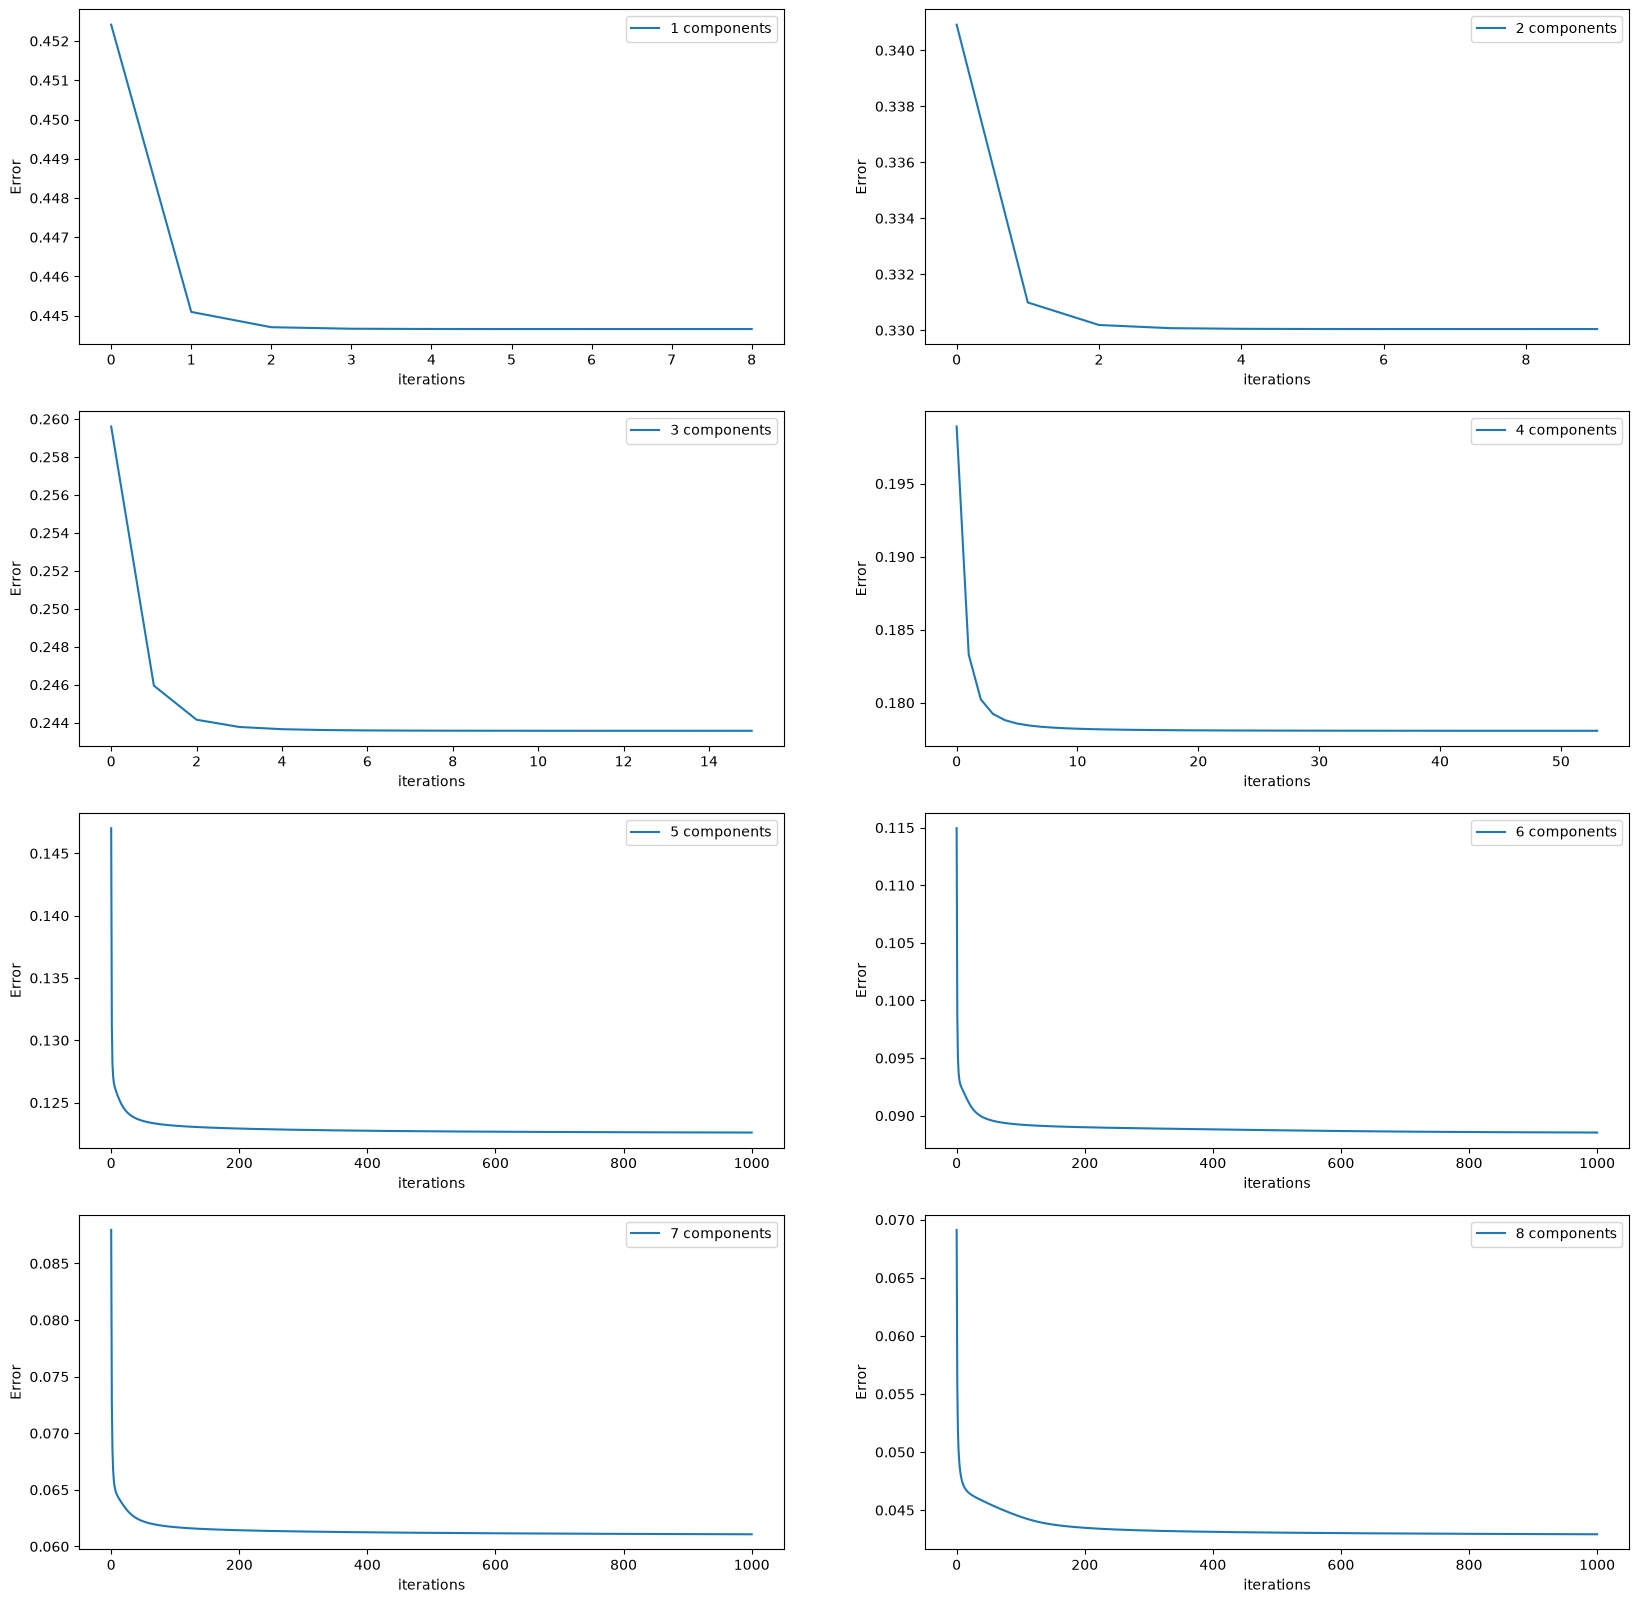

In [26]:
coefs={}
fig =plt.figure(figsize=(20,20))
value = 421
for d in range(1,9):
    data_matrix,errors_list = PCA_imputation(data_array.copy(),dimension=d)
    #print(min(errors_list))
    ax = fig.add_subplot(value)
    ax.plot([x for x in range(len(errors_list))],errors_list,label =f"{d} components")
    ax.set_xlabel("iterations")
    ax.set_ylabel("Error")
    nans_where= np.argwhere(np.isnan(data_array))
    indexlisttranspose = np.array(nans_where).T.tolist()
    X = data_total[tuple(indexlisttranspose)]

    y = data_matrix[tuple(indexlisttranspose)]

    coefs[d]=np.corrcoef(X,y)[1,0]
    ax.legend()
    
    value+=1
plt.show()

Text(0.5, 0, 'Principal Components(M)')

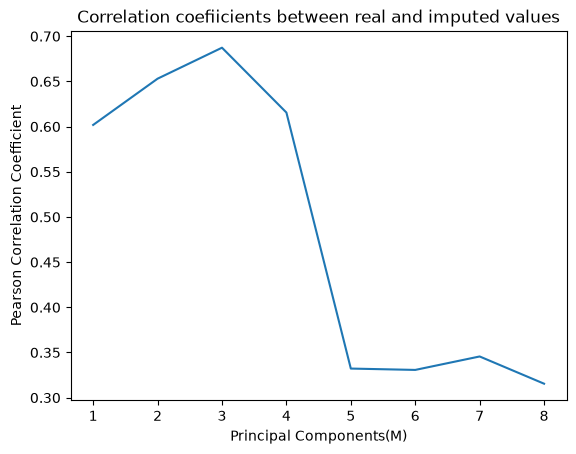

In [27]:
plt.plot(list(coefs.keys()),list(coefs.values()))
plt.title("Correlation coefiicients between real and imputed values")
plt.ylabel("Pearson Correlation Coefficient")
plt.xlabel("Principal Components(M)")

#### For nulls_percentage = 20%

In [28]:
cleared_df = scaled_df.mask(np.random.random(scaled_df.shape) < .2)
cleared_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     390 non-null    float64
 1   zn       411 non-null    float64
 2   indus    389 non-null    float64
 3   chas     397 non-null    float64
 4   nox      416 non-null    float64
 5   rm       395 non-null    float64
 6   age      402 non-null    float64
 7   dis      392 non-null    float64
 8   rad      402 non-null    float64
 9   tax      386 non-null    float64
 10  ptratio  412 non-null    float64
 11  lstat    405 non-null    float64
 12  medv     395 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [29]:
data_array = cleared_df.to_numpy(dtype='float', na_value=np.nan)


The algorithm converges after 9 iterations
The algorithm converges after 19 iterations
The algorithm converges after 110 iterations


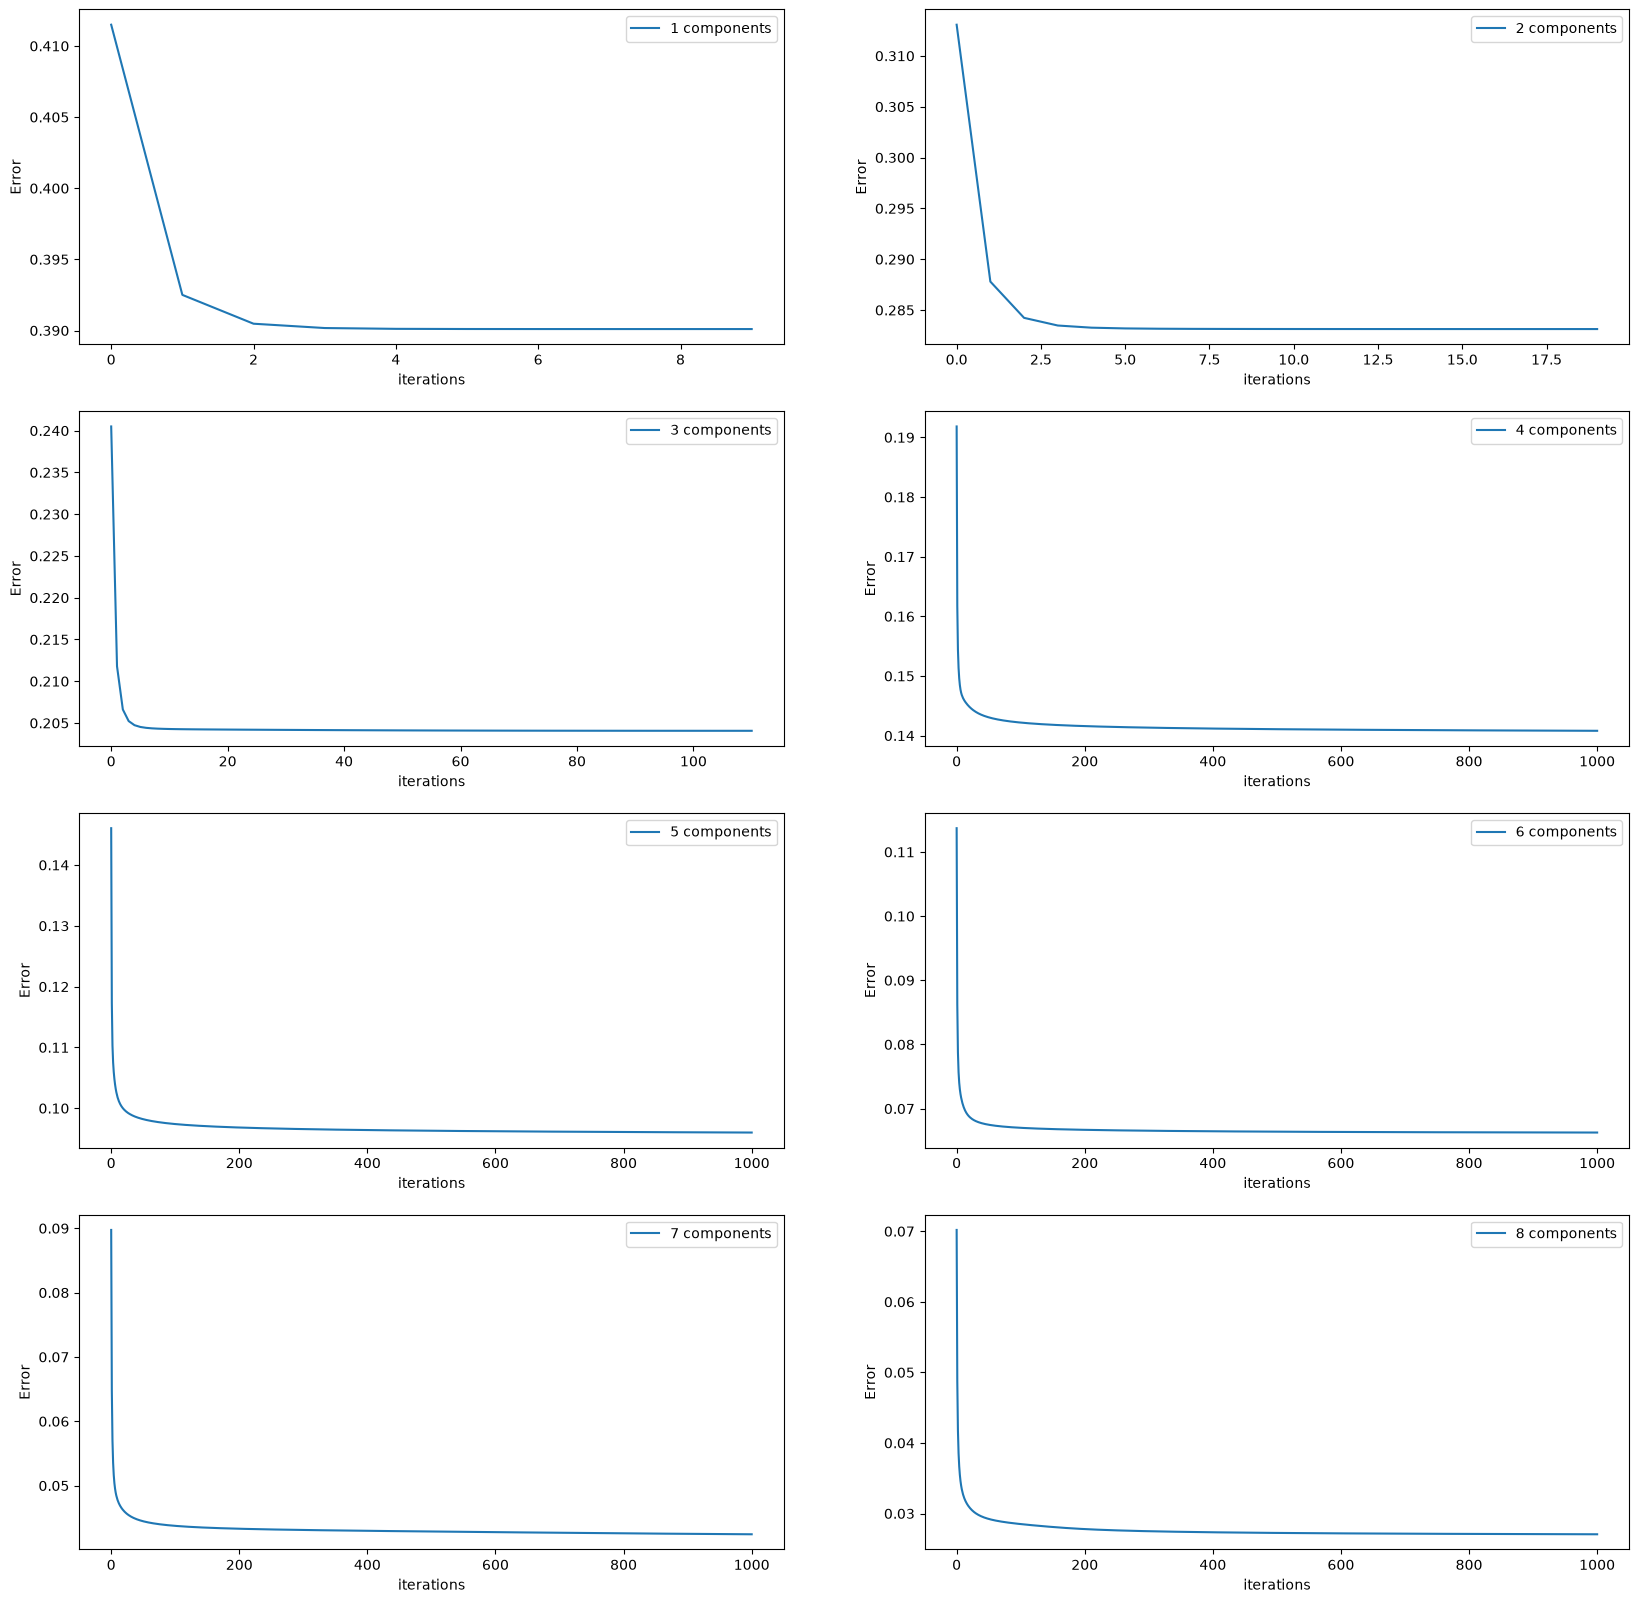

In [30]:
coefs={}
fig =plt.figure(figsize=(20,20))
value = 421
for d in range(1,9):
    data_matrix,errors_list = PCA_imputation(data_array.copy(),dimension=d)
    #print(min(errors_list))
    ax = fig.add_subplot(value)
    ax.plot([x for x in range(len(errors_list))],errors_list,label =f"{d} components")
    ax.set_xlabel("iterations")
    ax.set_ylabel("Error")
    nans_where= np.argwhere(np.isnan(data_array))
    indexlisttranspose = np.array(nans_where).T.tolist()
    X = data_total[tuple(indexlisttranspose)]

    y = data_matrix[tuple(indexlisttranspose)]

    coefs[d]=np.corrcoef(X,y)[1,0]
    ax.legend()
    
    value+=1
plt.show()

Text(0.5, 0, 'Principal Components(M)')

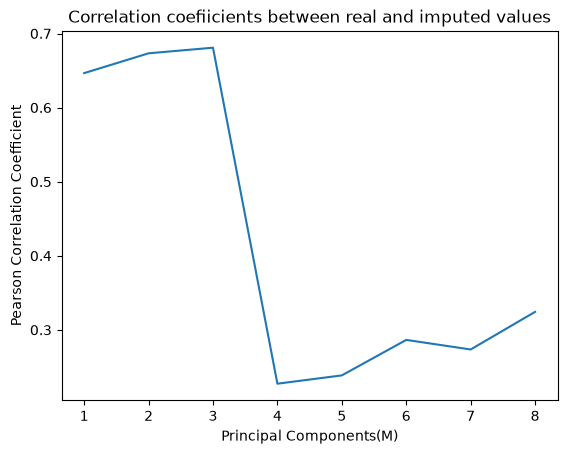

In [31]:
plt.plot(list(coefs.keys()),list(coefs.values()))
plt.title("Correlation coefiicients between real and imputed values")
plt.ylabel("Pearson Correlation Coefficient")
plt.xlabel("Principal Components(M)")

### We can notice that using principal components =3 gives the highest correlation between the real values and the imputed ones so we can be confident that the imputed values are close to the real values replaced with nan.